In [10]:
# %%
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["CUDA_MODULE_LOADING"] = "LAZY"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

import numpy as np
import tensorflow as tf
import keras
from keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# ---- StateFarm paths ----
BASE_DIR = "/home/lurpd/DevelopmentWSL2/Datasets/statefarmdataset"
TRAIN_DIR = os.path.join(BASE_DIR, "imgs/train")
# TEST_DIR = os.path.join(BASE_DIR, "imgs/test")  # optional later

# ---- Training params ----
IMG_SIZE = 128
BATCH = 16          # start stable; bump to 32 later if it runs clean
SEED = 42
VAL_SPLIT = 0.2
WD = 1e-5
EPOCHS = 50


TF: 2.21.0-dev20251017
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
# %%
# Data generators (simple + stable)
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode="nearest"
)

val_gen = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT)

train_generator = train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH,
    class_mode="categorical",
    subset="training",
    seed=SEED,
    shuffle=True
)

val_generator = val_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="rgb",
    batch_size=BATCH,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print("Classes:", train_generator.class_indices)
print("NUM_CLASSES:", NUM_CLASSES)


Found 13975 images belonging to 10 classes.
Found 3487 images belonging to 10 classes.
Classes: {'c0': 0, 'c1': 1, 'c2': 2, 'c3': 3, 'c4': 4, 'c5': 5, 'c6': 6, 'c7': 7, 'c8': 8, 'c9': 9}
NUM_CLASSES: 10


In [12]:
# %%
# Simple CNN (scratch) with a stable head (GAP instead of Flatten)
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, 3, padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(WD)),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(WD)),
    layers.MaxPooling2D(2),

    layers.Conv2D(128, 3, padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(WD)),
    layers.MaxPooling2D(2),

    layers.Conv2D(256, 3, padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(WD)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l2(WD)),
    layers.Dropout(0.35),

    layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,778 (1.74 MB)

 Trainable params: 456,778 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# %%
# Warmup (forces PTX JIT for this exact shape early, reduces random mid-fit crashes)
x_warm = tf.random.uniform((BATCH, IMG_SIZE, IMG_SIZE, 3))
_ = model(x_warm, training=False)
print("Warmup OK")


Warmup OK


In [14]:
# %%
# Class weights (optional but usually helpful)
labels = np.unique(train_generator.classes)
weights = compute_class_weight(
    class_weight="balanced",
    classes=labels,
    y=train_generator.classes
)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)


Class weights: {0: np.float64(0.8941138835572616), 1: np.float64(0.9953703703703703), 2: np.float64(0.9793272599859846), 3: np.float64(0.9651243093922652), 4: np.float64(0.9611416781292985), 5: np.float64(0.967797783933518), 6: np.float64(0.9644582470669427), 7: np.float64(1.1398858075040783), 8: np.float64(1.1502057613168724), 9: np.float64(1.0390334572490707)}


In [15]:
# %%
# Compile + train
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"],
    jit_compile=False
)

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint("statefarm_simple_best.keras", monitor="val_accuracy",
                    save_best_only=True, mode="max")
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)


Epoch 1/50


/home/lurpd/DevelopmentWSL2/DistractionAI/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


874/874 ━━━━━━━━━━━━━━━━━━━━ 30s 33ms/step - accuracy: 0.1053 - loss: 2.3075 - val_accuracy: 0.0969 - val_loss: 2.3041 - learning_rate: 1.0000e-04
Epoch 2/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.1489 - loss: 2.2550 - val_accuracy: 0.1887 - val_loss: 2.1544 - learning_rate: 1.0000e-04
Epoch 3/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.1985 - loss: 2.1191 - val_accuracy: 0.2458 - val_loss: 2.0112 - learning_rate: 1.0000e-04
Epoch 4/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.2343 - loss: 2.0134 - val_accuracy: 0.3000 - val_loss: 1.9201 - learning_rate: 1.0000e-04
Epoch 5/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accuracy: 0.2689 - loss: 1.9131 - val_accuracy: 0.2848 - val_loss: 1.8722 - learning_rate: 1.0000e-04
Epoch 6/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.3142 - loss: 1.8261 - val_accuracy: 0.3286 - val_loss: 1.7664 - learning_rate: 1.0000e-04
Epoch 7/50
874/874 ━━━━━━━━━━━━━━━━━━━━ 29s 33ms/step - accurac

              precision    recall  f1-score   support

          c0       0.96      0.30      0.46       390
          c1       0.56      0.99      0.71       350
          c2       0.84      0.62      0.71       356
          c3       0.46      0.95      0.62       361
          c4       0.75      0.53      0.62       363
          c5       0.99      0.93      0.96       360
          c6       0.99      0.58      0.73       362
          c7       0.84      0.95      0.90       306
          c8       0.78      0.58      0.67       303
          c9       0.68      0.73      0.70       336

    accuracy                           0.71      3487
   macro avg       0.79      0.72      0.71      3487
weighted avg       0.79      0.71      0.70      3487



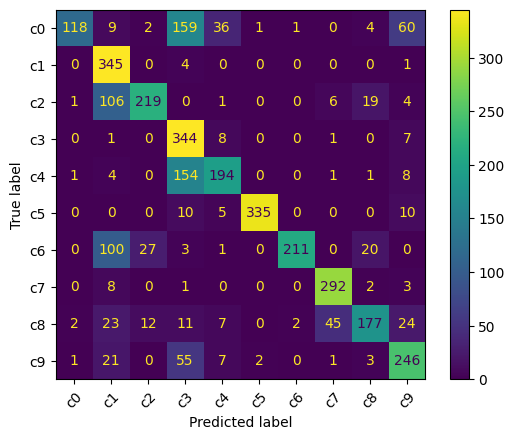

In [16]:
# %%
# Evaluate
val_generator.reset()
val_preds = model.predict(val_generator, verbose=0)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_generator.classes

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(xticks_rotation=45)
plt.show()


In [17]:
# %%
# Save final
model.save("statefarm_simple_final.keras")
print("Saved: statefarm_simple_final.keras")


Saved: statefarm_simple_final.keras


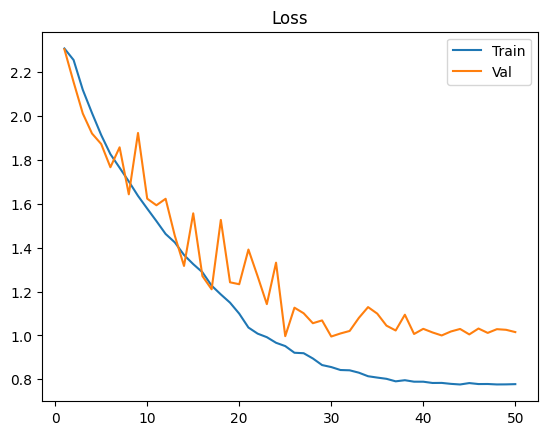

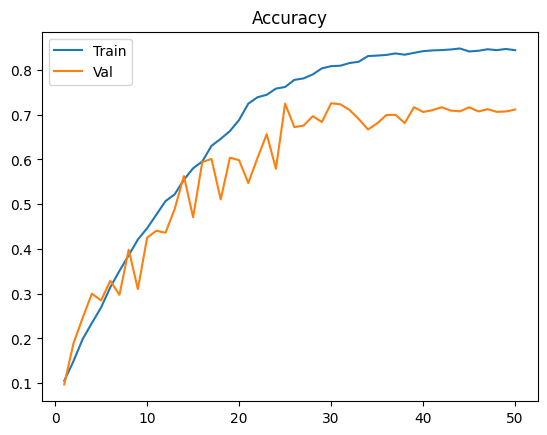

In [18]:
# %%
# Plot curves
tr_loss = history.history["loss"]
val_loss = history.history["val_loss"]
tr_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
ep = range(1, len(tr_loss) + 1)

plt.plot(ep, tr_loss, label="Train")
plt.plot(ep, val_loss, label="Val")
plt.title("Loss")
plt.legend()
plt.show()

plt.plot(ep, tr_acc, label="Train")
plt.plot(ep, val_acc, label="Val")
plt.title("Accuracy")
plt.legend()
plt.show()
